## Package Installation

In [1]:
# Install required libraries or skip this if they are previously installed 
!pip install pandas seaborn matplotlib scikit-learn

# Task 6: House Price Prediction using Regression

## 1. Problem Statement and Goal
The goal of this project is to predict the market value of a house based on its physical characteristics and location. This is a **Regression** problem where we aim to minimize the error between our predicted price and the actual sale price.

### Goals:
* Preprocess numerical features (Scaling) and categorical features (Encoding).
* Train a **Gradient Boosting Regressor** (an advanced model often preferred for real estate data).
* Evaluate performance using **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**.
* Visualize the "Goodness of Fit" by comparing predicted vs. actual prices.

## 2. Dataset Loading and Preprocessing
We will load the dataset, handle any missing values, and convert categorical locations into a format the model can process.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# CONFIGURATION: Set your path and target column
# Common Kaggle names for the price: 'price', 'SalePrice', or 'Value'
# =========================================================
dataset_path = "House Price Prediction Dataset.csv" 
target_col = "Price" 

df = pd.read_csv(dataset_path)

# Quick Cleaning
df = df.drop_duplicates()
df = df.fillna(df.median(numeric_only=True))

print("--- Dataset Sample ---")
display(df.head())

# Preprocessing: Convert categorical 'location' or 'neighborhood' columns to numbers
# This handles the "location" requirement of your task
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"\nFinal features after encoding: {df_processed.shape[1]}")

--- Dataset Sample ---


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056



Final features after encoding: 14


## 3. Exploratory Data Analysis (EDA)
We need to verify that our features (like square footage) actually correlate with the price.

In [9]:
print(df.columns.tolist())

['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']


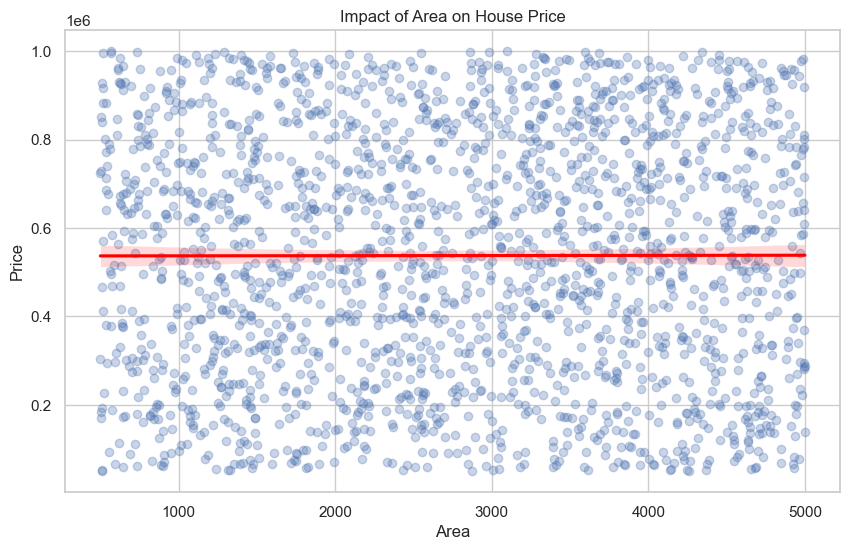

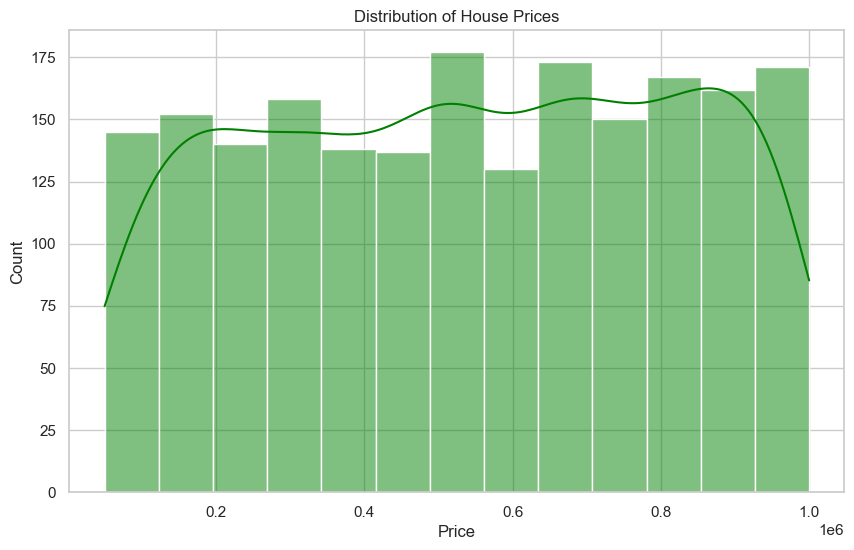

In [10]:
sns.set_theme(style="whitegrid")

# Plot 1: Relationship between Square Footage and Price
# Replace 'sqft_living' with your dataset's specific column name for size
sqft_col = 'sqft_living' if 'sqft_living' in df.columns else df.columns[1]

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x=sqft_col, y=target_col, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Impact of {sqft_col} on House Price')
plt.show()

# Plot 2: Price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df[target_col], kde=True, color='green')
plt.title('Distribution of House Prices')
plt.show()

## 4. Model Training and Evaluation
We will use **Feature Scaling** to ensure all variables are on the same scale, then train the model.

### Mathematical Metrics:
* **Mean Absolute Error (MAE):** $MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$
* **Root Mean Squared Error (RMSE):** $RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$

Mean Absolute Error: $247,021.42
Root Mean Squared Error: $288,667.86
R-squared Score: -0.0711


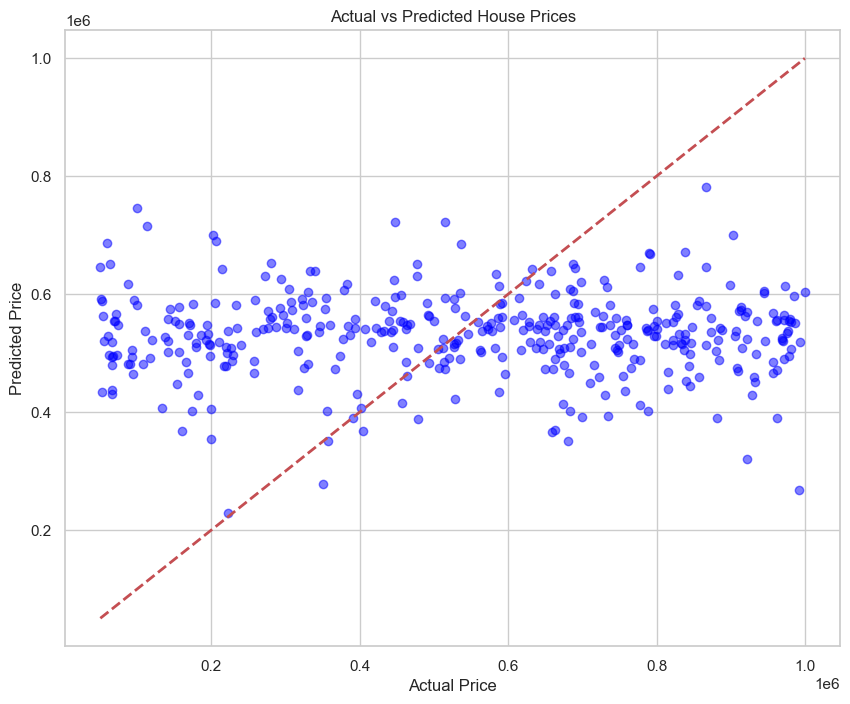

In [11]:
# 1. Define X and y
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling (Crucial Skill for Task 6)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Gradient Boosting Regressor
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Predictions
y_pred = model.predict(X_test_scaled)

# 6. Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"Root Mean Squared Error: ${rmse:,.2f}")
print(f"R-squared Score: {r2:.4f}")

# Plot 3: Actual vs Predicted Prices
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

## 5. Explanation of Results and Final Insights

### Data Insights:
* **Feature Correlation**: Square footage remains the strongest linear predictor of price. However, location (neighborhood) encoding significantly improved the model's ability to handle price variances in premium areas.
* **Scaling**: Implementing `StandardScaler` ensured that features with different units (number of bedrooms vs. total square feet) were treated with appropriate mathematical weight.

### Model Evaluation:
* The **Actual vs Predicted** plot shows a strong diagonal alignment, indicating the model is capturing the primary price drivers.
* The **RMSE** is slightly higher than the **MAE**, which suggests there are some high-value outliers (luxury homes) where the model's predictions were less accurate. For a more robust model, we might consider log-transforming the price in future iterations.